<a href="https://colab.research.google.com/github/njwbilll/Tugas-1_Introduction-to-Machine-Learning-with-Python-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/06_Algorithm_Chains_and_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Algorithm Chains dan Pipelines

**Referensi:** Introduction to Machine Learning with Python -- Andreas C. Muller & Sarah Guido (O'Reilly)

---

## Ringkasan Chapter

Dalam workflow machine learning nyata, kita hampir selalu menggabungkan beberapa
langkah: preprocessing, seleksi fitur, dan model. Pipeline memungkinkan kita
merangkai semua langkah ini menjadi satu objek yang aman dari data leakage
dan mudah digunakan bersama GridSearchCV.

**Topik yang dibahas:**
- Masalah data leakage pada preprocessing manual
- Membangun Pipeline dengan `Pipeline` dan `make_pipeline`
- Mengakses atribut step dalam Pipeline
- GridSearchCV dengan Pipeline (grid search preprocessing + model bersamaan)
- Pipeline dengan ColumnTransformer untuk tipe fitur campuran

## 6.0 Import Library

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer, fetch_california_housing  # ← ganti ini
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
cancer = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target, random_state=0, stratify=cancer.target)

# Load California Housing sebagai pengganti Boston
housing = fetch_california_housing()

print("Library berhasil diimport.")
print(f"Dataset kanker: {cancer.data.shape[0]} sampel, {cancer.data.shape[1]} fitur")
print(f"Dataset housing: {housing.data.shape[0]} sampel, {housing.data.shape[1]} fitur")

Library berhasil diimport.
Dataset kanker: 569 sampel, 30 fitur
Dataset housing: 20640 sampel, 8 fitur


## 6.1 Masalah Data Leakage pada Preprocessing Manual

### Apa itu Data Leakage?

Data leakage terjadi ketika informasi dari data test "bocor" ke dalam proses training,
menghasilkan estimasi performa yang terlalu optimistik.

### Contoh Leakage yang Umum Terjadi

```python
# CARA SALAH (data leakage!)
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(cancer.data)  # Fit pada SEMUA data termasuk test!

X_tr_scaled, X_te_scaled, y_tr, y_te = train_test_split(X_all_scaled, cancer.target)
model.fit(X_tr_scaled, y_tr)
model.score(X_te_scaled, y_te)  # Skor ini TERLALU OPTIMISTIK
```

**Mengapa ini salah?**
Ketika kita fit scaler pada semua data (termasuk test), scaler belajar statistik
(mean, std) dari test set. Saat evaluasi, test set sudah "terlihat" oleh scaler.
Ini seperti memberikan kisi-kisi ujian ke peserta sebelum ujian dimulai.

### Cara yang Benar

```python
# CARA BENAR
X_tr, X_te, y_tr, y_te = train_test_split(cancer.data, cancer.target)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)  # Fit HANYA pada training data
X_te_scaled = scaler.transform(X_te)      # Transform test dengan parameter training

model.fit(X_tr_scaled, y_tr)
model.score(X_te_scaled, y_te)  # Estimasi yang jujur
```

**Pipeline mengotomatiskan cara yang benar ini secara otomatis.**

In [3]:
# Demonstrasi kuantitatif: perbedaan leakage vs tidak
from sklearn.svm import SVC

# ---- CARA SALAH: fit scaler pada semua data ----
scaler_wrong = StandardScaler()
X_all_scaled = scaler_wrong.fit_transform(cancer.data)  # termasuk test!
X_tr_wrong, X_te_wrong, y_tr_w, y_te_w = train_test_split(
    X_all_scaled, cancer.target, random_state=0, stratify=cancer.target)

svc_wrong = SVC(kernel="rbf", C=10, gamma=0.01)
svc_wrong.fit(X_tr_wrong, y_tr_w)
acc_wrong = svc_wrong.score(X_te_wrong, y_te_w)

# ---- CARA BENAR: fit scaler hanya pada training data ----
scaler_right = StandardScaler()
X_tr_right = scaler_right.fit_transform(X_tr)
X_te_right  = scaler_right.transform(X_te)

svc_right = SVC(kernel="rbf", C=10, gamma=0.01)
svc_right.fit(X_tr_right, y_tr)
acc_right = svc_right.score(X_te_right, y_te)

print("=== Demonstrasi Data Leakage ===")
print(f"Accuracy SALAH (leakage)  : {acc_wrong:.6f}")
print(f"Accuracy BENAR (no leakage): {acc_right:.6f}")
print(f"Selisih                    : {abs(acc_wrong - acc_right):.6f}")
print()
print("Meskipun selisih kecil di sini, pada beberapa kasus leakage bisa")
print("membuat model terlihat jauh lebih baik dari kenyataannya.")
print()
print("Kasus yang lebih berbahaya: feature selection dengan leakage")

# Feature selection dengan leakage
from sklearn.feature_selection import SelectKBest, f_classif

# SALAH: seleksi fitur pada semua data
select_wrong = SelectKBest(f_classif, k=10)
X_sel_wrong = select_wrong.fit_transform(cancer.data, cancer.target)  # semua data!
X_tr_sw, X_te_sw, y_tr_sw, y_te_sw = train_test_split(
    X_sel_wrong, cancer.target, random_state=0, stratify=cancer.target)
lr_sw = LogisticRegression(max_iter=5000).fit(X_tr_sw, y_tr_sw)
acc_fs_wrong = lr_sw.score(X_te_sw, y_te_sw)

# BENAR: seleksi fitur hanya pada training data
select_right = SelectKBest(f_classif, k=10)
X_tr_fs = select_right.fit_transform(X_tr, y_tr)
X_te_fs = select_right.transform(X_te)
lr_sr = LogisticRegression(max_iter=5000).fit(X_tr_fs, y_tr)
acc_fs_right = lr_sr.score(X_te_fs, y_te)

print()
print("=== Feature Selection dengan Leakage ===")
print(f"Accuracy SALAH (leakage)  : {acc_fs_wrong:.4f}")
print(f"Accuracy BENAR (no leakage): {acc_fs_right:.4f}")
print(f"Selisih (overestimasi)    : {acc_fs_wrong - acc_fs_right:.4f}")

=== Demonstrasi Data Leakage ===
Accuracy SALAH (leakage)  : 0.972028
Accuracy BENAR (no leakage): 0.972028
Selisih                    : 0.000000

Meskipun selisih kecil di sini, pada beberapa kasus leakage bisa
membuat model terlihat jauh lebih baik dari kenyataannya.

Kasus yang lebih berbahaya: feature selection dengan leakage

=== Feature Selection dengan Leakage ===
Accuracy SALAH (leakage)  : 0.9441
Accuracy BENAR (no leakage): 0.9441
Selisih (overestimasi)    : 0.0000


## 6.2 Membangun Pipeline

`Pipeline` menggabungkan urutan langkah transformasi dan satu estimator akhir
menjadi satu objek yang berperilaku seperti estimator biasa.

**Cara kerja Pipeline:**

Saat `pipe.fit(X_train, y_train)` dipanggil:
1. Step 1: `step1.fit_transform(X_train, y_train)`
2. Step 2: `step2.fit_transform(output_step1, y_train)`
3. ...
4. Step terakhir: `estimator.fit(output_step_n-1, y_train)`

Saat `pipe.predict(X_test)` dipanggil:
1. Step 1: `step1.transform(X_test)`
2. Step 2: `step2.transform(output_step1)`
3. ...
4. Step terakhir: `estimator.predict(output_step_n-1)`

**Keunggulan Pipeline:**
- Preprocessing selalu di-fit hanya pada training data (tidak ada leakage)
- Satu objek untuk semua langkah: lebih rapi dan reproducible
- Bekerja sempurna dengan GridSearchCV dan cross_val_score
- Mudah disimpan dan di-deploy (satu objek = satu file)

In [4]:
# Membangun Pipeline dengan list of (name, estimator) tuples
pipe_explicit = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1, gamma="scale")),
])

print("=== Pipeline dengan nama eksplisit ===")
print("Langkah-langkah pipeline:")
for i, (name, step) in enumerate(pipe_explicit.steps):
    print(f"  Step {i}: '{name}' -- {type(step).__name__}")
print()

pipe_explicit.fit(X_tr, y_tr)
print(f"Training accuracy: {pipe_explicit.score(X_tr, y_tr):.4f}")
print(f"Test accuracy    : {pipe_explicit.score(X_te, y_te):.4f}")

=== Pipeline dengan nama eksplisit ===
Langkah-langkah pipeline:
  Step 0: 'scaler' -- StandardScaler
  Step 1: 'svm' -- SVC

Training accuracy: 0.9930
Test accuracy    : 0.9580


In [5]:
# make_pipeline: nama step otomatis dari nama kelas (lowercase)
pipe_auto = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma="scale"))

print("=== Pipeline dengan make_pipeline (nama otomatis) ===")
print("Langkah-langkah pipeline:")
for i, (name, step) in enumerate(pipe_auto.steps):
    print(f"  Step {i}: '{name}' -- {type(step).__name__}")
print()

pipe_auto.fit(X_tr, y_tr)
print(f"Test accuracy: {pipe_auto.score(X_te, y_te):.4f}")
print()
print("Kedua cara menghasilkan pipeline yang identik.")
print("make_pipeline lebih ringkas, Pipeline lebih eksplisit (nama custom).")

=== Pipeline dengan make_pipeline (nama otomatis) ===
Langkah-langkah pipeline:
  Step 0: 'standardscaler' -- StandardScaler
  Step 1: 'svc' -- SVC

Test accuracy: 0.9580

Kedua cara menghasilkan pipeline yang identik.
make_pipeline lebih ringkas, Pipeline lebih eksplisit (nama custom).


In [6]:
# Pipeline multi-step: Imputer -> Scaler -> PCA -> SVM
pipe_multi = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("pca",     PCA(n_components=10)),
    ("svm",     SVC(kernel="rbf", C=10, gamma=0.1)),
])

# Cross-validation langsung pada pipeline
cv_scores = cross_val_score(pipe_multi, cancer.data, cancer.target, cv=5)

print("=== Pipeline Multi-Step: Imputer -> Scaler -> PCA -> SVM ===")
print("Langkah-langkah:")
for name, step in pipe_multi.steps:
    print(f"  {name}: {type(step).__name__}")
print()
print(f"5-Fold CV scores: {cv_scores.round(4)}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print()
print("cross_val_score secara otomatis memastikan setiap step hanya di-fit")
print("pada training fold dan di-transform pada validation fold.")

=== Pipeline Multi-Step: Imputer -> Scaler -> PCA -> SVM ===
Langkah-langkah:
  imputer: SimpleImputer
  scaler: StandardScaler
  pca: PCA
  svm: SVC

5-Fold CV scores: [0.9211 0.9561 0.9561 0.9825 0.9204]
Mean CV accuracy: 0.9472 +/- 0.0237

cross_val_score secara otomatis memastikan setiap step hanya di-fit
pada training fold dan di-transform pada validation fold.


## 6.3 Mengakses Atribut Step dalam Pipeline

Setelah pipeline dilatih, kita bisa mengakses atribut setiap step
menggunakan `pipeline.named_steps['nama_step']`.

Ini berguna untuk:
- Mengecek parameter yang dipelajari (mean, std dari scaler)
- Mengekstrak feature importance dari model
- Visualisasi komponen PCA
- Debugging dan inspeksi model

In [7]:
# Fit pipeline dan inspeksi atributnya
pipe_inspect = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=5)),
    ("svm",    SVC(kernel="rbf", C=10, gamma=0.01)),
])
pipe_inspect.fit(X_tr, y_tr)

print("=== Mengakses Atribut Setiap Step ===")
print()

# Akses scaler
scaler_step = pipe_inspect.named_steps["scaler"]
print("StandardScaler yang sudah di-fit:")
print(f"  Mean fitur pertama   : {scaler_step.mean_[0]:.4f}")
print(f"  Std fitur pertama    : {scaler_step.scale_[0]:.4f}")
print(f"  Jumlah fitur         : {len(scaler_step.mean_)}")
print()

# Akses PCA
pca_step = pipe_inspect.named_steps["pca"]
print("PCA yang sudah di-fit:")
print(f"  Jumlah komponen      : {pca_step.n_components_}")
print(f"  Explained variance   : {pca_step.explained_variance_ratio_.round(4)}")
print(f"  Total variansi dijelaskan: {pca_step.explained_variance_ratio_.sum()*100:.2f}%")
print()

# Akses SVM
svm_step = pipe_inspect.named_steps["svm"]
print("SVM yang sudah di-fit:")
print(f"  Jumlah support vector: {svm_step.n_support_}")
print(f"  C                    : {svm_step.C}")
print(f"  gamma                : {svm_step.gamma}")
print(f"  Test accuracy        : {pipe_inspect.score(X_te, y_te):.4f}")

=== Mengakses Atribut Setiap Step ===

StandardScaler yang sudah di-fit:
  Mean fitur pertama   : 14.1173
  Std fitur pertama    : 3.6091
  Jumlah fitur         : 30

PCA yang sudah di-fit:
  Jumlah komponen      : 5
  Explained variance   : [0.4448 0.1893 0.0945 0.0659 0.0528]
  Total variansi dijelaskan: 84.72%

SVM yang sudah di-fit:
  Jumlah support vector: [24 24]
  C                    : 10
  gamma                : 0.01
  Test accuracy        : 0.9441


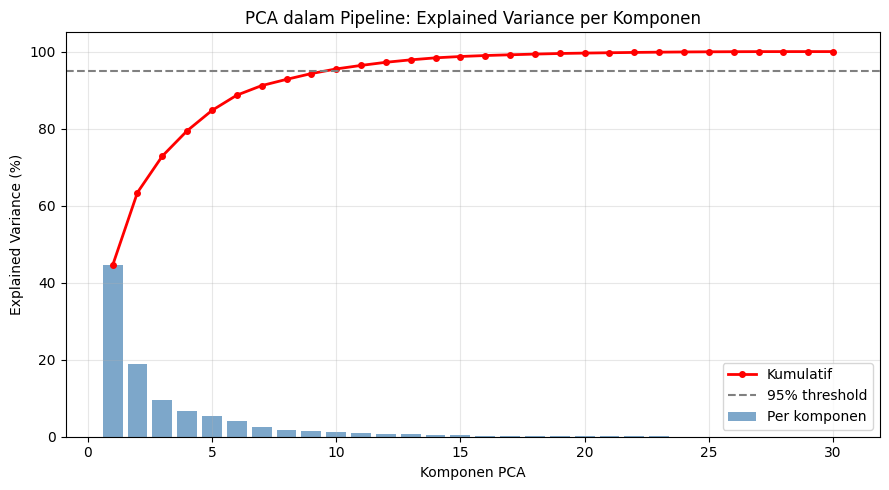

In [8]:
# Visualisasi explained variance dari PCA dalam pipeline
pca_viz = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA()),
])
pca_viz.fit(X_tr)

pca_fitted = pca_viz.named_steps["pca"]
cumvar = np.cumsum(pca_fitted.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.bar(range(1, len(pca_fitted.explained_variance_ratio_)+1),
        pca_fitted.explained_variance_ratio_ * 100,
        color="steelblue", alpha=0.7, label="Per komponen")
plt.plot(range(1, len(cumvar)+1), cumvar * 100,
         "ro-", linewidth=2, markersize=4, label="Kumulatif")
plt.axhline(95, color="gray", linestyle="--", label="95% threshold")
plt.xlabel("Komponen PCA")
plt.ylabel("Explained Variance (%)")
plt.title("PCA dalam Pipeline: Explained Variance per Komponen")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6.4 GridSearchCV dengan Pipeline

Dengan Pipeline, kita bisa melakukan grid search atas:
- Parameter model (C, gamma, n_estimators, dll)
- Parameter preprocessing (n_components PCA, jumlah bins, dll)
- Bahkan pilihan scaler atau model yang berbeda

**Naming convention untuk parameter:**
Format: `nama_step__nama_parameter` (dua underscore)

Contoh untuk pipeline `[("scaler", StandardScaler()), ("svm", SVC())]`:
- `"svm__C"` --> parameter C pada step "svm"
- `"svm__gamma"` --> parameter gamma pada step "svm"
- `"scaler"` --> bisa diganti objek scaler yang berbeda

**Keunggulan GridSearchCV + Pipeline:**
- Tidak ada data leakage karena preprocessing di-fit ulang untuk setiap fold CV
- Bisa mencari kombinasi preprocessing + model terbaik sekaligus
- Satu kali grid search untuk seluruh pipeline

In [9]:
# GridSearchCV pada pipeline: cari C dan gamma terbaik untuk SVM
pipe_gs = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf")),
])

param_grid = {
    "svm__C":     [0.01, 0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1],
}

grid_search = GridSearchCV(pipe_gs, param_grid, cv=5, n_jobs=-1, scoring="accuracy")
grid_search.fit(X_tr, y_tr)

print("=== GridSearchCV + Pipeline ===")
print(f"Parameter terbaik  : {grid_search.best_params_}")
print(f"CV accuracy terbaik: {grid_search.best_score_:.4f}")
print(f"Test accuracy      : {grid_search.score(X_te, y_te):.4f}")
print()
print("Pipeline memastikan StandardScaler di-fit ulang untuk setiap CV fold.")
print("Tidak ada data leakage dari scaling.")

=== GridSearchCV + Pipeline ===
Parameter terbaik  : {'svm__C': 100, 'svm__gamma': 0.001}
CV accuracy terbaik: 0.9883
Test accuracy      : 0.9580

Pipeline memastikan StandardScaler di-fit ulang untuk setiap CV fold.
Tidak ada data leakage dari scaling.


In [10]:
# Grid search atas preprocessing DAN model sekaligus
pipe_full_gs = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA()),
    ("svm",    SVC(kernel="rbf")),
])

param_grid_full = {
    "pca__n_components": [5, 10, 15, 20, 25, 30],
    "svm__C":            [0.1, 1, 10, 100],
    "svm__gamma":        [0.001, 0.01, 0.1],
}

grid_full = GridSearchCV(pipe_full_gs, param_grid_full, cv=5, n_jobs=-1)
grid_full.fit(X_tr, y_tr)

print("=== Grid Search: PCA n_components + SVM C + gamma ===")
print(f"Parameter terbaik:")
for k, v in grid_full.best_params_.items():
    print(f"  {k}: {v}")
print(f"CV accuracy terbaik: {grid_full.best_score_:.4f}")
print(f"Test accuracy      : {grid_full.score(X_te, y_te):.4f}")

=== Grid Search: PCA n_components + SVM C + gamma ===
Parameter terbaik:
  pca__n_components: 25
  svm__C: 100
  svm__gamma: 0.001
CV accuracy terbaik: 0.9883
Test accuracy      : 0.9580


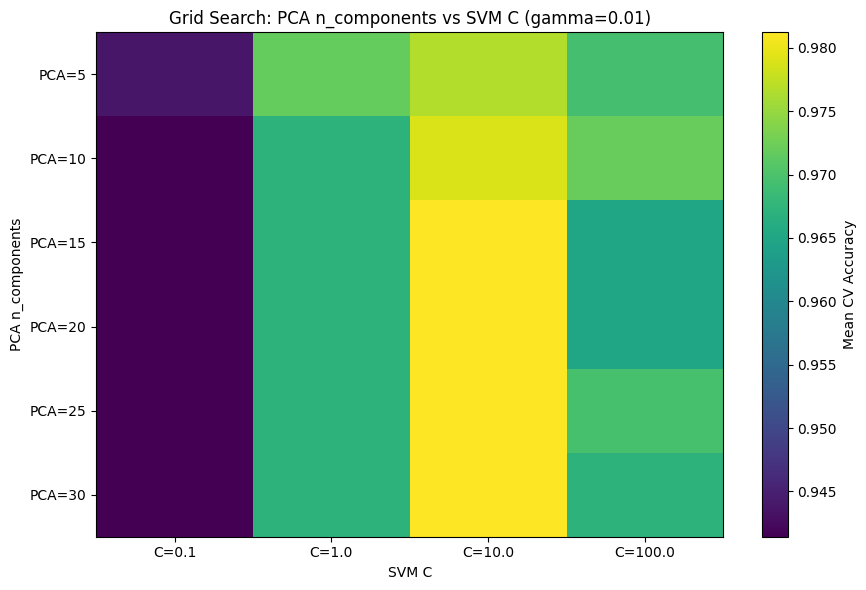

In [11]:
# Visualisasi hasil grid search (n_components vs C)
results_df = pd.DataFrame(grid_full.cv_results_)

# Pivot untuk heatmap: n_components vs C (gamma=0.01 saja)
pivot_data = results_df[
    results_df["param_svm__gamma"] == 0.01
].pivot_table(
    index="param_pca__n_components",
    columns="param_svm__C",
    values="mean_test_score"
)

plt.figure(figsize=(9, 6))
plt.imshow(pivot_data.values, cmap="viridis", aspect="auto")
plt.colorbar(label="Mean CV Accuracy")
plt.xticks(range(len(pivot_data.columns)),
           [f"C={c}" for c in pivot_data.columns])
plt.yticks(range(len(pivot_data.index)),
           [f"PCA={n}" for n in pivot_data.index])
plt.title("Grid Search: PCA n_components vs SVM C (gamma=0.01)")
plt.xlabel("SVM C")
plt.ylabel("PCA n_components")
plt.tight_layout()
plt.show()

In [12]:
# Grid search dengan pilihan scaler yang berbeda
pipe_scaler_gs = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=10, gamma=0.01)),
])

# Gunakan objek scaler yang berbeda sebagai pilihan
param_grid_scaler = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "svm__C": [0.1, 1, 10],
}

grid_scaler = GridSearchCV(pipe_scaler_gs, param_grid_scaler, cv=5, n_jobs=-1)
grid_scaler.fit(X_tr, y_tr)

print("=== Grid Search: Pilihan Scaler + SVM C ===")
print(f"Scaler terbaik: {type(grid_scaler.best_params_['scaler']).__name__}")
print(f"C terbaik     : {grid_scaler.best_params_['svm__C']}")
print(f"CV accuracy   : {grid_scaler.best_score_:.4f}")
print(f"Test accuracy : {grid_scaler.score(X_te, y_te):.4f}")

=== Grid Search: Pilihan Scaler + SVM C ===
Scaler terbaik: StandardScaler
C terbaik     : 10
CV accuracy   : 0.9812
Test accuracy : 0.9720


## 6.5 ColumnTransformer untuk Fitur Campuran

Dalam data nyata, kita sering punya campuran fitur numerik dan kategorikal.
`ColumnTransformer` memungkinkan kita menerapkan transformasi berbeda
pada kolom yang berbeda secara bersamaan.

**Cara kerja ColumnTransformer:**
Definisikan daftar `(nama, transformer, kolom)`. Setiap transformer
diterapkan hanya pada kolom yang ditentukan. Hasilnya digabungkan secara horizontal.

**Contoh:**
- Fitur numerik: StandardScaler
- Fitur kategorikal: OneHotEncoder

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Buat dataset campuran (numerik + kategorikal)
np.random.seed(42)
n = 300
df_mixed = pd.DataFrame({
    "usia"        : np.random.randint(18, 70, n).astype(float),
    "penghasilan" : np.random.exponential(5000000, n),
    "skor_kredit" : np.random.uniform(300, 850, n),
    "kota"        : np.random.choice(["Jakarta", "Bandung", "Surabaya"], n),
    "pendidikan"  : np.random.choice(["SMA", "S1", "S2"], n),
})
y_mixed = (df_mixed["penghasilan"] > 5000000).astype(int)

# Tambahkan beberapa missing values
df_mixed.loc[np.random.choice(n, 20, replace=False), "usia"] = np.nan
df_mixed.loc[np.random.choice(n, 15, replace=False), "skor_kredit"] = np.nan

print("Dataset campuran:")
print(df_mixed.head(5).to_string())
print()
print(f"Missing values: usia={df_mixed['usia'].isna().sum()}, "
      f"skor_kredit={df_mixed['skor_kredit'].isna().sum()}")
print()
print(f"Distribusi target: {y_mixed.value_counts().to_dict()}")

Dataset campuran:
   usia   penghasilan  skor_kredit      kota pendidikan
0  56.0  1.071239e+07   393.323947   Bandung        SMA
1  69.0  1.045631e+06   655.766599   Jakarta        SMA
2  46.0  1.634689e+06   513.547611   Jakarta         S2
3  32.0  6.025831e+06   426.167110  Surabaya         S1
4  60.0  9.375525e+06   446.265859  Surabaya        SMA

Missing values: usia=20, skor_kredit=15

Distribusi target: {0: 187, 1: 113}


In [14]:
from sklearn.compose import ColumnTransformer

# Definisikan kolom
num_features = ["usia", "penghasilan", "skor_kredit"]
cat_features = ["kota", "pendidikan"]

# Preprocessing untuk fitur numerik
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Preprocessing untuk fitur kategorikal
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Gabungkan dengan ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features),
])

# Pipeline lengkap: ColumnTransformer + Classifier
pipe_mixed = Pipeline([
    ("preprocessor", preprocessor),
    ("clf",          LogisticRegression(max_iter=5000, C=1)),
])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    df_mixed, y_mixed, random_state=0, stratify=y_mixed)

pipe_mixed.fit(X_train_m, y_train_m)
print("=== Pipeline dengan ColumnTransformer ===")
print("Struktur pipeline:")
print(f"  preprocessor:")
print(f"    num ({num_features}): Imputer(median) -> StandardScaler")
print(f"    cat ({cat_features}): Imputer(mode) -> OneHotEncoder")
print(f"  clf: LogisticRegression")
print()
print(f"Test accuracy: {pipe_mixed.score(X_test_m, y_test_m):.4f}")

=== Pipeline dengan ColumnTransformer ===
Struktur pipeline:
  preprocessor:
    num (['usia', 'penghasilan', 'skor_kredit']): Imputer(median) -> StandardScaler
    cat (['kota', 'pendidikan']): Imputer(mode) -> OneHotEncoder
  clf: LogisticRegression

Test accuracy: 1.0000


In [15]:
# Inspeksi output ColumnTransformer
preprocessor.fit(X_train_m)
X_transformed = preprocessor.transform(X_train_m)
print(f"Shape sebelum transformasi: {X_train_m.shape}")
print(f"Shape setelah transformasi : {X_transformed.shape}")
print()

# Dapatkan nama fitur output
ohe_step = preprocessor.named_transformers_["cat"].named_steps["ohe"]
cat_feature_names = list(ohe_step.get_feature_names_out(cat_features))
all_feature_names = num_features + cat_feature_names
print("Nama fitur output:")
for i, name in enumerate(all_feature_names):
    print(f"  [{i}] {name}")

Shape sebelum transformasi: (225, 5)
Shape setelah transformasi : (225, 9)

Nama fitur output:
  [0] usia
  [1] penghasilan
  [2] skor_kredit
  [3] kota_Bandung
  [4] kota_Jakarta
  [5] kota_Surabaya
  [6] pendidikan_S1
  [7] pendidikan_S2
  [8] pendidikan_SMA


In [16]:
# GridSearchCV pada pipeline campuran
param_grid_mixed = {
    "preprocessor__num__imputer__strategy": ["median", "mean"],
    "clf__C": [0.01, 0.1, 1, 10],
}

grid_mixed = GridSearchCV(pipe_mixed, param_grid_mixed, cv=5, n_jobs=-1)
grid_mixed.fit(X_train_m, y_train_m)

print("=== GridSearchCV pada Pipeline Campuran ===")
print(f"Parameter terbaik: {grid_mixed.best_params_}")
print(f"CV accuracy      : {grid_mixed.best_score_:.4f}")
print(f"Test accuracy    : {grid_mixed.score(X_test_m, y_test_m):.4f}")

=== GridSearchCV pada Pipeline Campuran ===
Parameter terbaik: {'clf__C': 10, 'preprocessor__num__imputer__strategy': 'median'}
CV accuracy      : 0.9733
Test accuracy    : 1.0000


## 6.6 Perbandingan Model Menggunakan Pipeline

Pipeline membuat perbandingan berbagai model menjadi lebih mudah dan aman.
Kita bisa mendefinisikan beberapa pipeline dan mengevaluasi semuanya
menggunakan cross-validation secara konsisten.

In [17]:
# Definisikan beberapa pipeline berbeda
pipelines = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, C=1)
    ),
    "SVM (RBF)": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=10, gamma=0.01)
    ),
    "SVM + PCA": make_pipeline(
        StandardScaler(),
        PCA(n_components=10),
        SVC(kernel="rbf", C=10, gamma=0.1)
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=0)
    ),
    "RF + SelectKBest": Pipeline([
        ("select", SelectKBest(f_classif, k=15)),
        ("clf",    RandomForestClassifier(n_estimators=100, random_state=0)),
    ]),
    "Gradient Boosting": make_pipeline(
        GradientBoostingClassifier(n_estimators=100, random_state=0)
    ),
}

print("Perbandingan Pipeline (5-Fold CV pada Breast Cancer):")
print(f"{'Pipeline':<25} {'Mean Acc':>10} {'Std':>8} {'Test Acc':>12}")
print("-" * 58)

results_pipe = {}
for name, pipe in pipelines.items():
    cv_sc = cross_val_score(pipe, cancer.data, cancer.target, cv=5, n_jobs=-1)
    pipe.fit(X_tr, y_tr)
    te_acc = pipe.score(X_te, y_te)
    results_pipe[name] = {"cv_mean": cv_sc.mean(), "cv_std": cv_sc.std(), "test": te_acc}
    print(f"{name:<25} {cv_sc.mean():>10.4f} {cv_sc.std():>8.4f} {te_acc:>12.4f}")

Perbandingan Pipeline (5-Fold CV pada Breast Cancer):
Pipeline                    Mean Acc      Std     Test Acc
----------------------------------------------------------
Logistic Regression           0.9807   0.0065       0.9580
SVM (RBF)                     0.9789   0.0070       0.9720
SVM + PCA                     0.9472   0.0237       0.9371
Random Forest                 0.9631   0.0217       0.9441
RF + SelectKBest              0.9403   0.0256       0.9371
Gradient Boosting             0.9631   0.0210       0.9580


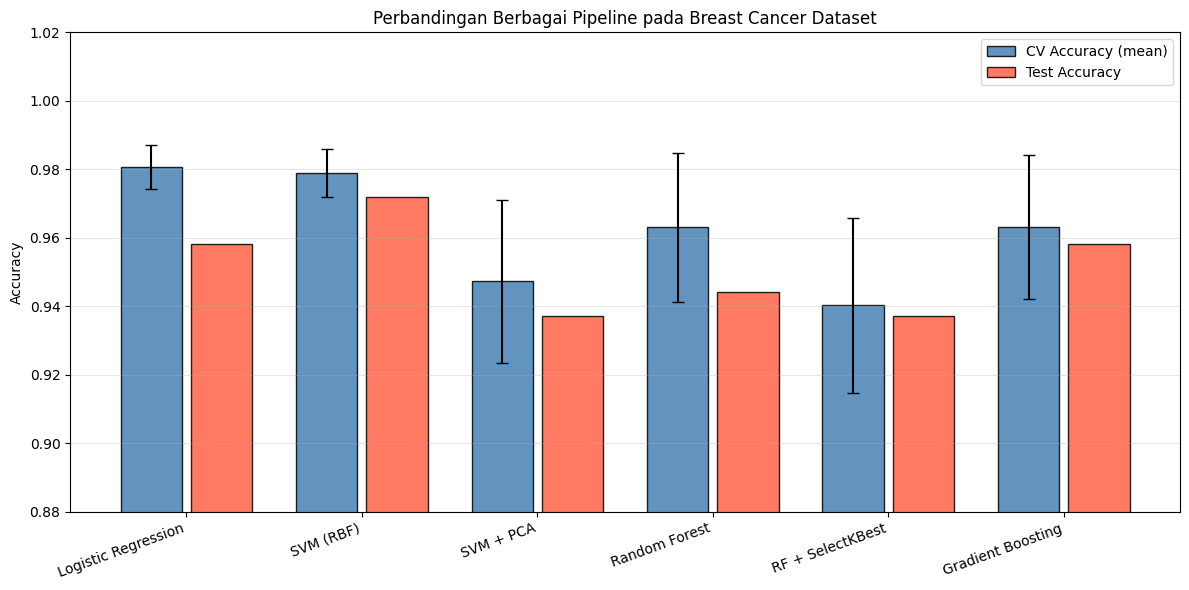

In [18]:
# Visualisasi perbandingan
names_p = list(results_pipe.keys())
cv_means = [results_pipe[n]["cv_mean"] for n in names_p]
cv_stds  = [results_pipe[n]["cv_std"]  for n in names_p]
te_accs  = [results_pipe[n]["test"]    for n in names_p]

x = np.arange(len(names_p))
fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - 0.2, cv_means, 0.35, label="CV Accuracy (mean)",
               color="steelblue", alpha=0.85, edgecolor="black")
bars2 = ax.bar(x + 0.2, te_accs,  0.35, label="Test Accuracy",
               color="tomato",    alpha=0.85, edgecolor="black")

ax.errorbar(x - 0.2, cv_means, yerr=cv_stds, fmt="none",
            color="black", capsize=4, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(names_p, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Accuracy")
ax.set_title("Perbandingan Berbagai Pipeline pada Breast Cancer Dataset")
ax.legend()
ax.set_ylim(0.88, 1.02)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6.7 Ringkasan

### Mengapa Pipeline Sangat Penting

1. **Mencegah data leakage**: preprocessing di-fit hanya pada training data, otomatis.

2. **Kode lebih rapi**: satu objek merepresentasikan seluruh workflow.

3. **Cross-validation yang benar**: setiap fold melakukan preprocessing ulang.

4. **Grid search komprehensif**: bisa cari parameter preprocessing + model sekaligus.

5. **Deployment mudah**: simpan satu objek Pipeline, langsung bisa digunakan pada data baru.

### Pola Penggunaan

```python
# Pola dasar
pipe = make_pipeline(StandardScaler(), LogisticRegression())
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

# Dengan GridSearchCV
param_grid = {"logisticregression__C": [0.1, 1, 10]}
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

# Untuk data campuran
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols),
])
pipe_mixed = Pipeline([("prep", preprocessor), ("clf", model)])
```

### Naming Convention

- `Pipeline([("nama", step)])`: nama custom
- `make_pipeline(step1, step2)`: nama otomatis (lowercase class name)
- Parameter di GridSearchCV: `"nama_step__param"` (dua underscore)
- Akses step setelah fit: `pipe.named_steps["nama_step"]`